# Diffusion-style trajectories versus OT rays in two dimensions

This notebook generates `fig:generative-diffusion-versus-ot-2d` and the schedule-comparison panels used nearby in the text. It uses the same three-Dirac / centered-Gaussian geometry as the preceding diffusion figure, but now in the sampling direction: particles start from the Gaussian in the middle and are transported toward the three target atoms.

The main diffusion panel follows the variance-preserving Ornstein--Uhlenbeck noising path used in `notebooks/6-diffusion.ipynb`,
$$
    Z_\tau=e^{-\tau}X+\sqrt{1-e^{-2\tau}}Y,
$$
and integrates the associated reverse probability-flow ODE. The additional panels compare it with the linear bridge and with a deliberately non-variance-preserving overshooting bridge. The cosine finite-time variance-preserving coefficients are not displayed separately because they are exactly the same OU family after the time change $\tau=-\log\cos(\pi t/2)$, hence they have the same spatial trajectories.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if ROOT.name == "notebooks-figures":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks-figures"))

from figure_style import (
    BLUE,
    RED,
    DIRAC_MARKER_SIZE,
    figure_dir,
    interp_color,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

from matplotlib.collections import LineCollection
import ot

NAME = "generative-diffusion-versus-ot-2d"
out = figure_dir(NAME)
rng = np.random.default_rng(43)

For a general Gaussian noising interpolant
$$
    Z_t=a(t)X+b(t)Y, \qquad Y\sim\mathcal N(0,\sigma^2 I),
$$
the density is the Gaussian mixture
$$
    p_t(z)=\sum_j w_j\,\mathcal N\bigl(z; a(t)c_j, (b(t)\sigma)^2 I\bigr).
$$
The exact flow-matching velocity is
$$
    v_t(z)=a'(t)\,\mathbb E[X\mid Z_t=z]
        +b'(t)\,\mathbb E[Y\mid Z_t=z].
$$
Away from the times where $a(t)=0$, it can also be written in score form as
$$
    v_t(z)=\frac{a'(t)}{a(t)}z+
    \left(\frac{a'(t)b(t)^2}{a(t)}-b'(t)b(t)\right)\sigma^2\nabla\log p_t(z).
$$
The code checks this identity for the schedules where it is nonsingular and always integrates the conditional-expectation form. For the variance-preserving schedule $a(\tau)=e^{-\tau}$ and $b(\tau)=\sqrt{1-e^{-2\tau}}$, the formula reduces to the forward probability-flow velocity
$$
    v_\tau(z)=-z-\sigma^2\nabla\log p_\tau(z),
$$
so the sampling direction integrates $z+\sigma^2\nabla\log p_\tau(z)$ while decreasing $\tau$.

The third comparison panel uses the overshooting bridge $a(t)=(1-t)(1-2t)$, $b(t)=t$. It has the same endpoints but is not a time reparameterization of the linear or OU paths: the signal coefficient changes sign, so the intermediate mixture is reflected before collapsing to the Gaussian endpoint.


In [2]:
centers = np.array([[-1.02, -0.42], [1.02, -0.40], [0.00, 1.02]])
weights = np.ones(3) / 3
sigma = 0.24
N = 72
x = rng.normal(loc=[0.0, 0.0], scale=sigma, size=(N, 2))
y = np.repeat(centers, N // 3, axis=0)
if len(y) < N:
    y = np.vstack([y, centers[: N - len(y)]])
a = np.ones(N) / N
P = ot.emd(a, a, ot.dist(x, y, metric="sqeuclidean"))
match = P.argmax(axis=1)
ym = y[match]
xlim = (-1.48, 1.48)
ylim = (-0.90, 1.34)


In [3]:
def schedule_coefficients(name, t):
    """Return a, b, a', b' for Z_t=a(t)X+b(t)Y."""
    t = float(t)
    if name == "linear":
        return 1.0 - t, t, -1.0, 1.0
    if name == "vp":
        e = np.exp(-t)
        b = np.sqrt(max(1.0 - e**2, 1e-15))
        return e, b, -e, e**2 / b
    if name == "overshoot":
        # A deliberately non-VP bridge: the signal coefficient changes sign.
        return (1.0 - t) * (1.0 - 2.0 * t), t, 4.0 * t - 3.0, 1.0
    raise ValueError(f"Unknown schedule {name!r}")


# The ODE is integrated closer to the singular data endpoint than it is displayed.
# Paths are later thinned for vector export, keeping PDF size moderate.
schedule_times = {
    "linear": (0.995, 0.010, 560),
    "vp": (5.0, 0.003, 2200),
    "overshoot": (0.995, 0.010, 800),
}


def component_responsibilities(z, t, schedule):
    a_t, b_t, _, _ = schedule_coefficients(schedule, t)
    var = max((b_t * sigma) ** 2, 1e-14)
    means_t = a_t * centers
    diff = z[:, None, :] - means_t[None, :, :]
    logp = -0.5 * np.sum(diff**2, axis=-1) / var + np.log(weights)[None, :]
    logp -= logp.max(axis=1, keepdims=True)
    W = np.exp(logp)
    return W / W.sum(axis=1, keepdims=True)


def mixture_score(z, t, schedule):
    """Closed-form score of the Gaussian mixture p_t."""
    a_t, b_t, _, _ = schedule_coefficients(schedule, t)
    var = max((b_t * sigma) ** 2, 1e-14)
    W = component_responsibilities(z, t, schedule)
    means_t = a_t * centers
    return np.sum(W[:, :, None] * (means_t[None, :, :] - z[:, None, :]) / var, axis=1)


def conditional_x_mean(z, t, schedule):
    return component_responsibilities(z, t, schedule) @ centers


def schedule_velocity(z, t, schedule):
    """Noising-direction velocity for Z_t=a(t)X+b(t)Y."""
    a_t, b_t, da_t, db_t = schedule_coefficients(schedule, t)
    mx = conditional_x_mean(z, t, schedule)
    my = (z - a_t * mx) / max(b_t, 1e-14)
    return da_t * mx + db_t * my


def score_formula_velocity(z, t, schedule):
    """Same velocity written with the score; valid away from a_t=0."""
    a_t, b_t, da_t, db_t = schedule_coefficients(schedule, t)
    score = mixture_score(z, t, schedule)
    return (da_t / a_t) * z + ((da_t * b_t**2 / a_t) - db_t * b_t) * sigma**2 * score


# Guard against sign or scaling mistakes by checking the generic score identity
# away from singular times, and the two simplified closed forms used in the text.
check_rng = np.random.default_rng(123)
check_z = check_rng.normal(scale=0.7, size=(64, 2))
check_times = {
    "linear": (0.995, 0.75, 0.35, 0.08, 0.010),
    "vp": (5.0, 2.0, 0.7, 0.12, 0.003),
    "overshoot": (0.995, 0.75, 0.35, 0.12, 0.010),
}
for schedule, times in check_times.items():
    for check_t in times:
        a_t = schedule_coefficients(schedule, check_t)[0]
        if abs(a_t) < 1e-8:
            continue
        np.testing.assert_allclose(
            schedule_velocity(check_z, check_t, schedule),
            score_formula_velocity(check_z, check_t, schedule),
            rtol=2e-11,
            atol=2e-11,
        )
for check_t in check_times["linear"]:
    score = mixture_score(check_z, check_t, "linear")
    np.testing.assert_allclose(
        schedule_velocity(check_z, check_t, "linear"),
        -(check_z + check_t * sigma**2 * score) / (1.0 - check_t),
        rtol=2e-11,
        atol=2e-11,
    )
for check_t in check_times["vp"]:
    score = mixture_score(check_z, check_t, "vp")
    np.testing.assert_allclose(
        schedule_velocity(check_z, check_t, "vp"),
        -check_z - sigma**2 * score,
        rtol=2e-11,
        atol=2e-11,
    )


def rk4_step(z, t, dt, schedule):
    k1 = schedule_velocity(z, t, schedule)
    k2 = schedule_velocity(z + 0.5 * dt * k1, t + 0.5 * dt, schedule)
    k3 = schedule_velocity(z + 0.5 * dt * k2, t + 0.5 * dt, schedule)
    k4 = schedule_velocity(z + dt * k3, t + dt, schedule)
    return z + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def integrate_reverse(schedule):
    t_start, t_end, n_steps = schedule_times[schedule]
    tgrid = np.linspace(t_start, t_end, n_steps)
    z = x.copy()
    paths = [z.copy()]
    for k in range(len(tgrid) - 1):
        t = tgrid[k]
        dt = tgrid[k + 1] - tgrid[k]
        z = rk4_step(z, t, dt, schedule)
        paths.append(z.copy())
    return np.stack(paths, axis=1)


paths_by_schedule = {name: integrate_reverse(name) for name in ["linear", "vp", "overshoot"]}


def thin_paths(paths, max_points=240):
    """Keep dense integration for accuracy but export only a clean vector trace."""
    if paths.shape[1] <= max_points:
        return paths
    ind = np.unique(np.r_[np.linspace(0, paths.shape[1] - 1, max_points - 1, dtype=int), paths.shape[1] - 1])
    return paths[:, ind, :]


def endpoint_distances(paths):
    terminal = paths[:, -1, :]
    return np.min(np.linalg.norm(terminal[:, None, :] - centers[None, :, :], axis=-1), axis=1)


def segment_colors(num_points, alpha=0.32):
    s = np.linspace(0.0, 1.0, num_points - 1)
    return [(*interp_color(float(u)), alpha) for u in s]


def draw_on_axis(ax, paths, *, draw_starts=True):
    for pts in paths:
        segs = np.stack([pts[:-1], pts[1:]], axis=1)
        ax.add_collection(LineCollection(segs, colors=segment_colors(len(pts)), linewidths=0.46, zorder=1))
    if draw_starts:
        ax.scatter(x[:, 0], x[:, 1], s=DIRAC_MARKER_SIZE * 0.20, marker="o", color=RED, edgecolor="none", linewidth=0, alpha=0.54, zorder=3)
    ax.scatter(centers[:, 0], centers[:, 1], s=DIRAC_MARKER_SIZE * 0.52, marker="o", color=BLUE, edgecolor="none", linewidth=0, alpha=0.98, zorder=6)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    remove_axes(ax)


def draw(paths, filename):
    fig, ax = plt.subplots(figsize=(2.34, 2.12))
    draw_on_axis(ax, list(thin_paths(paths)))
    save_pdf(fig, out / filename, pad_inches=0.032)
    plt.close(fig)


s_ot = np.linspace(0.0, 1.0, 240)
ot_paths = np.stack([(1 - s_ot[:, None]) * x[i] + s_ot[:, None] * ym[i] for i in range(N)])

# Main Figure 14.4: variance-preserving diffusion-style flow versus OT rays.
draw(paths_by_schedule["vp"], "diffusion-curves.pdf")
draw(ot_paths, "ot-rays.pdf")

# Additional schedule-comparison panels assembled in LaTeX.
for schedule, filename in [
    ("linear", "schedule-linear.pdf"),
    ("vp", "schedule-vp.pdf"),
    ("overshoot", "schedule-overshoot.pdf"),
]:
    draw(paths_by_schedule[schedule], filename)

thumb_dir = ROOT / "notebooks-figures" / "thumbnails"
thumb_dir.mkdir(parents=True, exist_ok=True)
fig, axes = plt.subplots(1, 3, figsize=(7.25, 2.20), gridspec_kw={"wspace": 0.035})
for ax, schedule, title in zip(axes, ["linear", "vp", "overshoot"], ["linear", "VP / OU", "overshoot"]):
    draw_on_axis(ax, list(thin_paths(paths_by_schedule[schedule])))
    ax.text(0.5, -0.05, title, transform=ax.transAxes, ha="center", va="top", fontsize=9)
fig.savefig(thumb_dir / "generative-diffusion-versus-ot-2d.png", dpi=180, bbox_inches="tight", pad_inches=0.035)
plt.close(fig)

for name, paths in paths_by_schedule.items():
    dist = endpoint_distances(paths)
    print(
        f"{name}: final median distance={np.median(dist):.4f}, "
        f"90%={np.quantile(dist, 0.90):.4f}, max={np.max(dist):.4f}"
    )
print(f"Wrote panels to {out}")




linear: final median distance=0.0111, 90%=0.0145, max=0.0166
vp: final median distance=0.0219, 90%=0.0424, max=0.0590
overshoot: final median distance=0.0318, 90%=0.0360, max=0.0373
Wrote panels to /Users/gpeyre/Dropbox/github/ot4ml/latex/figures/generative-diffusion-versus-ot-2d


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


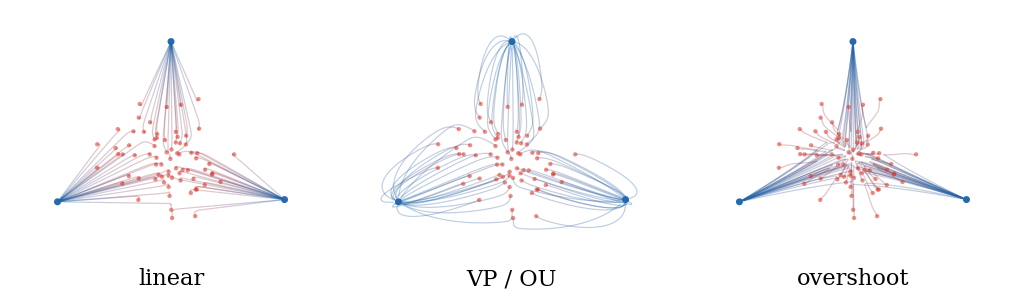

In [4]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/generative-diffusion-versus-ot-2d.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/generative-diffusion-versus-ot-2d.png")
display(Image(filename=str(_thumb)))
